# Day 8 - Build the Model
**Codomax AI & ML Internship**
**Author:** Shiyas S

Tasks: Create a Linear Regression model using Scikit-learn and train it with the dataset.

## 1. Load the Cleaned Dataset

In [1]:
import pandas as pd

df = pd.read_csv("student_scores_cleaned.csv")
df.head()

,StudyHours,Score
0,4.4,43.3
1,9.6,87.3
2,7.6,67.8
3,6.4,56.1
4,2.4,14.2


## 2. Define Features (X) and Target (y)

In [2]:
X = df[["StudyHours"]]
y = df["Score"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (50, 1)
y shape: (50,)


## 3. Train-Test Split

In [3]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 40
Testing samples: 10


## 4. Create and Train the Linear Regression Model

Scikit-learn's `LinearRegression` finds the best-fit line by learning the
slope (m) and intercept (b) that minimize the error between predicted and
actual scores on the training data.

In [4]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

print("Model trained successfully!")
print("Slope (m):", model.coef_[0])
print("Intercept (b):", model.intercept_)

Model trained successfully!
Slope (m): 8.628717396388677
Intercept (b): 3.3353139672017633


## 5. Understand What the Model Learned

The equation our model learned is:

**Score = slope × StudyHours + intercept**

This tells us roughly how many points a score increases for every extra hour studied.

In [5]:
slope = model.coef_[0]
intercept = model.intercept_

print(f"Learned equation: Score = {slope:.2f} x StudyHours + {intercept:.2f}")
print(f"Meaning: each extra study hour adds about {slope:.2f} points to the predicted score.")

Learned equation: Score = 8.63 x StudyHours + 3.34
Meaning: each extra study hour adds about 8.63 points to the predicted score.


## 6. Visualize the Fitted Line Against Actual Data

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


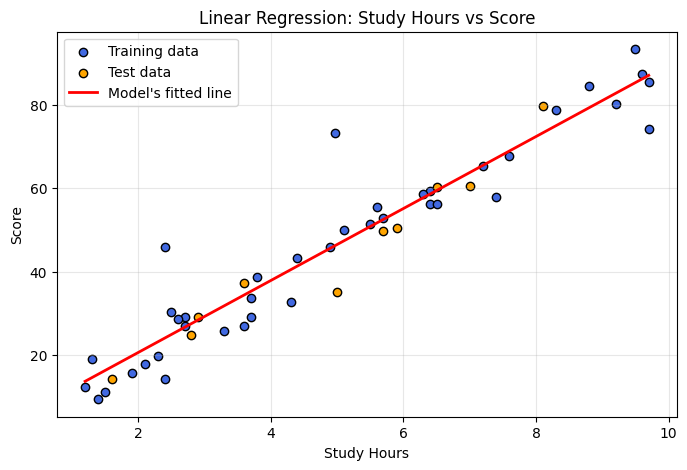

In [6]:
import matplotlib.pyplot as plt
import numpy as np

x_line = np.linspace(X["StudyHours"].min(), X["StudyHours"].max(), 100).reshape(-1, 1)
y_line = model.predict(x_line)

plt.figure(figsize=(8, 5))
plt.scatter(X_train, y_train, color="royalblue", edgecolor="black", label="Training data")
plt.scatter(X_test, y_test, color="orange", edgecolor="black", label="Test data")
plt.plot(x_line, y_line, color="red", linewidth=2, label="Model's fitted line")
plt.title("Linear Regression: Study Hours vs Score")
plt.xlabel("Study Hours")
plt.ylabel("Score")
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig("day8_fitted_line.png", dpi=150, bbox_inches="tight")
plt.show()

## 7. Save the Trained Model

We save the model to a file so we can reuse it later (Day 9 predictions,
Day 11 prediction app) without retraining it every time.

In [7]:
import joblib

joblib.dump(model, "student_score_model.pkl")
print("Model saved as student_score_model.pkl")

Model saved as student_score_model.pkl


## Summary
Today I:
- Split the cleaned dataset into training and test sets
- Created a `LinearRegression` model using Scikit-learn
- Trained it on the training data and found the learned slope and intercept
- Visualized the fitted line against both training and test data
- Saved the trained model as `student_score_model.pkl` for future use

Tomorrow (Day 9), I will use this saved model to generate predictions for new study-hour values.